# Milestone 2

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
import tarfile
import os
import glob
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import numpy as np
import time
import tempfile
import shutil

time_start = time.time()

In [20]:
DATA_ROOT = '/content/drive/MyDrive/MiDaS'
SMALL_TAR  = os.path.join(DATA_ROOT, 'MiDaS-60_small', 'MiDaS-60.tar.001')
LARGE_TARS = sorted(glob.glob(os.path.join(DATA_ROOT, 'MiDaS-60_large', 'MiDaS-60.tar.*')))

EXTRACT_SMALL = './root_small'
EXTRACT_LARGE = './root_large'

In [21]:
# helpers
def _extract_single(tar_path, dest):
    """Extract a single tar file to dest."""
    print(f"  Extracting {os.path.basename(tar_path)} → {dest} ...")
    with tarfile.open(tar_path) as tar:
        tar.extractall(dest)

def _extract_multipart(tar_paths, dest):
    """
    Concatenate multi-part tar files into a single temp file, then extract.
    This avoids streaming read bugs when part boundaries fall mid-block.
    """
    print(f"  Merging {len(tar_paths)} parts...")
    with tempfile.NamedTemporaryFile(suffix='.tar', delete=False) as tmp:
        tmp_path = tmp.name
        for part in tar_paths:
            print(f"    Appending {os.path.basename(part)} ...")
            with open(part, 'rb') as f:
                shutil.copyfileobj(f, tmp)

    print(f"  Extracting merged archive → {dest} ...")
    with tarfile.open(tmp_path, mode='r') as tar:
        tar.extractall(dest, filter='data')  # filter='data' suppresses the DeprecationWarning too

    os.remove(tmp_path)
    print("  Done. Temp file removed.")

In [22]:
# data loader
def load_data(variant='small', transform=None, batch_size=32, shuffle=True, num_workers=2):
    """
    Load the MiDaS-60 dataset for the given variant ('small' or 'large').

    - 'small' : single-part tar (MiDaS-60_small/MiDaS-60.tar.001)
    - 'large' : multi-part tar  (MiDaS-60_large/MiDaS-60.tar.001/.002/.003)

    Args:
        variant    : 'small' or 'large'
        transform  : Optional torchvision transform. Defaults to ToTensor() for the loader.
        batch_size : DataLoader batch size.
        shuffle    : Shuffle training loader.
        num_workers: DataLoader workers.

    Returns:
        train_loader, train_dataset, test_loader, test_dataset
    """
    assert variant in ('small', 'large'), "variant must be 'small' or 'large'"

    if variant == 'small':
        dest = EXTRACT_SMALL
        if not os.path.exists(dest):
            _extract_single(SMALL_TAR, dest)
        else:
            print(f"[small] Already extracted, skipping.")
    else:
        dest = EXTRACT_LARGE
        if not os.path.exists(dest):
            _extract_multipart(LARGE_TARS, dest)
        else:
            print(f"[large] Already extracted, skipping.")

    data_folder = os.listdir(dest)[0]
    data_path   = os.path.join(dest, data_folder)

    loader_transform = transform if transform is not None else transforms.ToTensor()

    train_dataset = datasets.ImageFolder(os.path.join(data_path, 'train'), transform=loader_transform)
    test_dataset  = datasets.ImageFolder(os.path.join(data_path, 'test'),  transform=loader_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle,  num_workers=num_workers)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,    num_workers=num_workers)

    return train_loader, train_dataset, test_loader, test_dataset

In [23]:
# visualization helpers
def show_class_samples(train_dataset, samples_per_class=4, title_prefix=''):
    """Display a grid of raw PIL images — one row per class."""
    idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
    class_samples = {}
    for path, label in train_dataset.samples:
        cls = idx_to_class[label]
        class_samples.setdefault(cls, []).append(path)

    classes   = sorted(class_samples.keys())
    n_classes = len(classes)

    fig, axes = plt.subplots(
        n_classes, samples_per_class,
        figsize=(samples_per_class*2, n_classes*1)
    )
    fig.suptitle(
        f"{title_prefix} — Sample Images per Class (Train, No Transform)",
        fontsize=12, y=1.01
    )

    for row, cls in enumerate(classes):
        paths = class_samples[cls][:samples_per_class]
        for col in range(samples_per_class):
            ax = axes[row, col] if n_classes > 1 else axes[col]
            if col < len(paths):
                ax.imshow(Image.open(paths[col]).convert('RGB'))
            else:
                ax.set_facecolor('#1a1a1a')
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(cls, fontsize=8, rotation=0, labelpad=70, va='center')

    plt.tight_layout()
    plt.show()


def plot_class_distribution(train_dataset, test_dataset, title_prefix=''):
    """
    Vertically stacked bar chart showing per-class train/test image counts.
    When perfectly balanced, all bars will be visually identical — confirming
    the finding at a glance.
    """
    classes      = sorted(train_dataset.classes)
    train_counts = Counter(label for _, label in train_dataset.samples)
    test_counts  = Counter(label for _, label in test_dataset.samples)

    train_vals = [train_counts[train_dataset.class_to_idx[c]] for c in classes]
    test_vals  = [test_counts [test_dataset.class_to_idx[c]]  for c in classes]

    x = np.arange(len(classes))
    width = 0.55

    fig, ax = plt.subplots(figsize=(max(10, len(classes) * 0.7), 6))

    bars_tr = ax.bar(x, train_vals, width, label='Train', color='#4C9BE8', alpha=0.88)
    bars_te = ax.bar(x, test_vals,  width, label='Test',  color='#F28C38', alpha=0.88,
                     bottom=train_vals)

    # Annotate train count inside the train segment
    for bar, tv in zip(bars_tr, train_vals):
        if tv > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                tv / 2,
                str(tv),
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold'
            )

    # Annotate test count inside the test segment
    for bar, tv, ev in zip(bars_te, train_vals, test_vals):
        if ev > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                tv + ev / 2,
                str(ev),
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold'
            )

    # Total on top of each bar
    for xi, (tv, ev) in enumerate(zip(train_vals, test_vals)):
        ax.text(xi, tv + ev + 0.5, str(tv + ev),
                ha='center', va='bottom', fontsize=8, color='#333333')

    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Number of Images')
    ax.set_title(f'{title_prefix} — Per-Class Train / Test Distribution', fontsize=12, pad=12)
    ax.legend(handles=[
        mpatches.Patch(color='#4C9BE8', alpha=0.88, label='Train'),
        mpatches.Patch(color='#F28C38', alpha=0.88, label='Test'),
    ])
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

def print_dataset_statistics(train_dataset, test_dataset, label=''):
    """Print per-class train counts and global totals."""
    idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
    train_counts = Counter(label_idx for _, label_idx in train_dataset.samples)

    header = f"  {label}  " if label else ""
    print("=" * 50)
    print(f"{header + 'CLASS-WISE COUNTS (Train)':^50}")
    print("=" * 50)
    print(f"  {'Class':<28} {'# Images':>10}")
    print("-" * 50)
    for idx, count in sorted(train_counts.items(), key=lambda x: idx_to_class[x[0]]):
        print(f"  {idx_to_class[idx]:<28} {count:>10}")
    print("=" * 50)
    print(f"  Total train images : {len(train_dataset):>6}")
    print(f"  Total test  images : {len(test_dataset):>6}")
    print(f"  Total overall      : {len(train_dataset)+len(test_dataset):>6}")
    print(f"  Number of classes  : {len(train_dataset.classes):>6}")
    print("=" * 50)


──────────────────────────────────────────────────
 SMALL DATASET
──────────────────────────────────────────────────
[small] Already extracted, skipping.
          SMALL  CLASS-WISE COUNTS (Train)        
  Class                          # Images
--------------------------------------------------
  acacia_log                          540
  acacia_planks                       540
  bed                                 540
  birch_log                           540
  birch_planks                        540
  bookshelf                           540
  bricks                              540
  chest                               540
  clay                                540
  coal_ore                            540
  cobblestone                         540
  crafting_table                      540
  crimson_planks                      540
  dark_oak_log                        540
  dark_oak_planks                     540
  diamond_ore                         540
  diorite                    

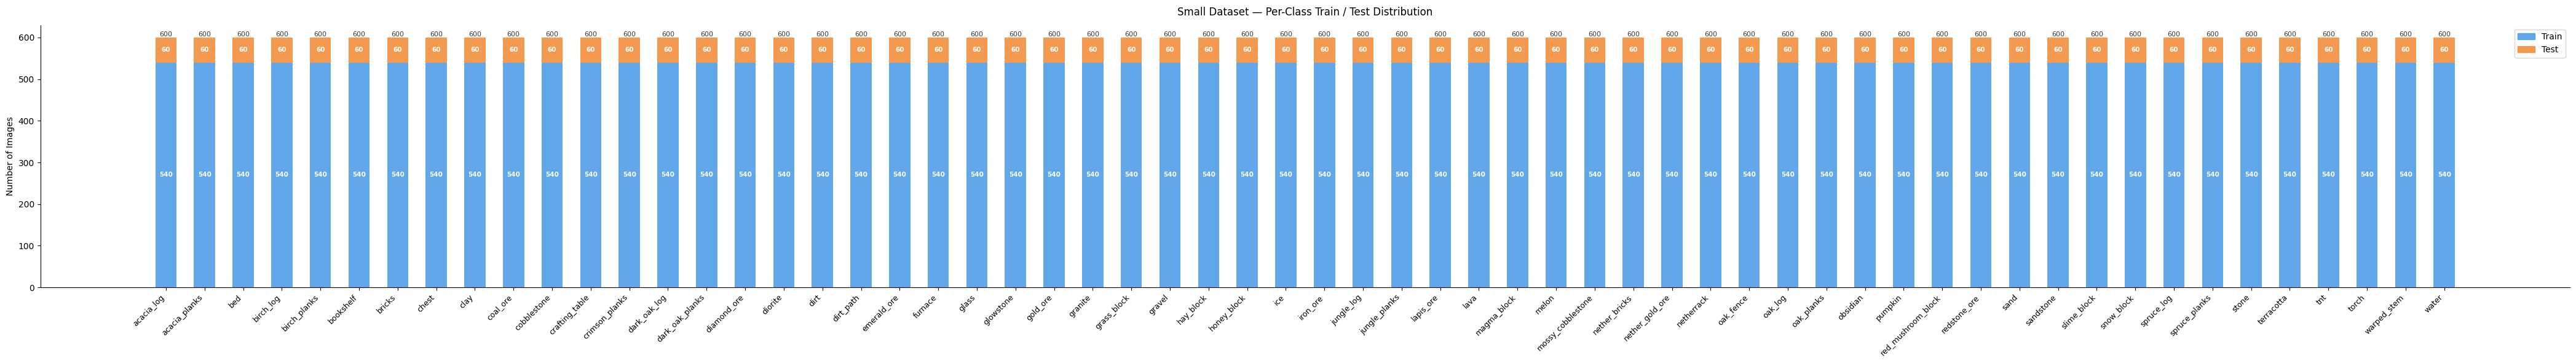

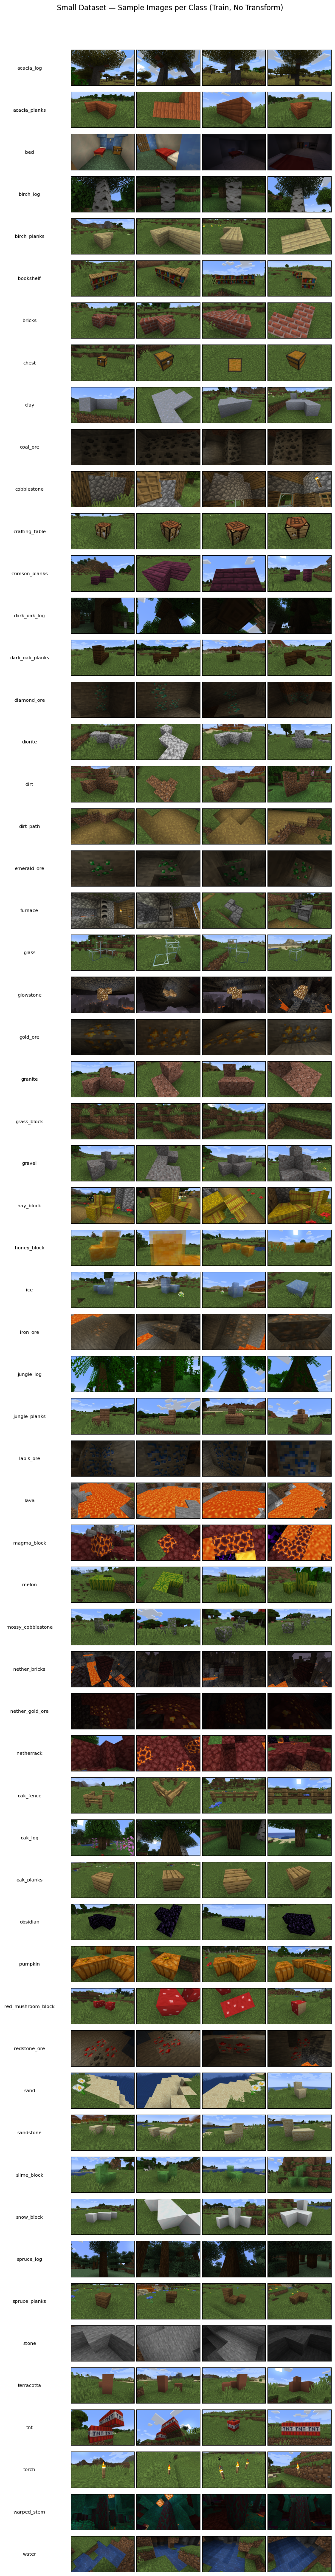

In [17]:
# Small dataset
print("\n" + "─"*50)
print(" SMALL DATASET")
print("─"*50)
train_loader_s, train_ds_s, test_loader_s, test_ds_s = load_data(variant='small')
print_dataset_statistics(train_ds_s, test_ds_s, label='SMALL')
plot_class_distribution(train_ds_s, test_ds_s,  title_prefix='Small Dataset')
show_class_samples(train_ds_s, samples_per_class=4, title_prefix='Small Dataset')

In [26]:
# Large dataset
print("\n" + "─"*50)
print(" LARGE DATASET")
print("─"*50)
train_loader_l, train_ds_l, test_loader_l, test_ds_l = load_data(variant='large')
print_dataset_statistics(train_ds_l, test_ds_l, label='LARGE')
plot_class_distribution(train_ds_l, test_ds_l,  title_prefix='Large Dataset')
show_class_samples(train_ds_l, samples_per_class=4, title_prefix='Large Dataset')


──────────────────────────────────────────────────
 LARGE DATASET
──────────────────────────────────────────────────
  Merging 3 parts...
    Appending MiDaS-60.tar.001 ...
    Appending MiDaS-60.tar.002 ...
    Appending MiDaS-60.tar.003 ...
  Extracting merged archive → ./root_large ...


ReadError: unexpected end of data

In [ ]:
time_end = time.time()
print(f"It took {(time_end - time_start)/60:.2f} minutes for this notebook to run!")

In [ ]:
# also print out the size of each image, channels